In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import itertools
import seaborn as sns
import statsmodels.formula.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices


In [3]:
from sklearn import datasets
from sklearn.feature_selection import RFE
import sklearn.metrics as metrics
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2, f_classif, mutual_info_classif

In [4]:
import pandas as pd
train = pd.read_csv("KDDTrain.csv",sep=',')
test = pd.read_csv("KDDTest.csv",sep=',')


In [5]:
train.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [6]:
train.tail()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.0,1.00,1.0,0.00,0.0,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.0,0.00,0.0,0.00,0.0,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.0,0.72,0.0,0.01,0.0,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.0,1.00,1.0,0.00,0.0,neptune,20
125972,0,tcp,ftp_data,SF,151,0,0,0,0,0,...,0.30,0.03,0.30,0.0,0.00,0.0,0.00,0.0,normal,21


In [7]:
columns=["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent","hot",
         "num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root","num_file_creations", 
         "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count","srv_count","serror_rate",
         "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
         "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
         "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
         "dst_host_srv_rerror_rate","attack","last_flag"] 

In [8]:
len(columns)

43

In [9]:
train.columns=columns
test.columns=columns

In [10]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,last_flag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [11]:
test.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,last_flag
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [12]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [13]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22544 non-null  int64  
 1   protocol_type                22544 non-null  object 
 2   service                      22544 non-null  object 
 3   flag                         22544 non-null  object 
 4   src_bytes                    22544 non-null  int64  
 5   dst_bytes                    22544 non-null  int64  
 6   land                         22544 non-null  int64  
 7   wrong_fragment               22544 non-null  int64  
 8   urgent                       22544 non-null  int64  
 9   hot                          22544 non-null  int64  
 10  num_failed_logins            22544 non-null  int64  
 11  logged_in                    22544 non-null  int64  
 12  num_compromised              22544 non-null  int64  
 13  root_shell      

In [14]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.00,0.00,0.00,7.479000e+03


In [15]:
#In attack_class normal means 0, DOS means 1, PROBE means 2, R2L means 3 and U2R means 4.
train.loc[train.attack=='normal','attack_class']=0

train.loc[(train.attack=='back') | (train.attack=='land') | (train.attack=='pod') | (train.attack=='neptune') | 
         (train.attack=='smurf') | (train.attack=='teardrop') | (train.attack=='apache2') | (train.attack=='udpstorm') | 
         (train.attack=='processtable') | (train.attack=='worm') | (train.attack=='mailbomb'),'attack_class']=1

train.loc[(train.attack=='satan') | (train.attack=='ipsweep') | (train.attack=='nmap') | (train.attack=='portsweep') | 
          (train.attack=='mscan') | (train.attack=='saint'),'attack_class']=2

train.loc[(train.attack=='guess_passwd') | (train.attack=='ftp_write') | (train.attack=='imap') | (train.attack=='phf') | 
          (train.attack=='multihop') | (train.attack=='warezmaster') | (train.attack=='warezclient') | (train.attack=='spy') | 
          (train.attack=='xlock') | (train.attack=='xsnoop') | (train.attack=='snmpguess') | (train.attack=='snmpgetattack') | 
          (train.attack=='httptunnel') | (train.attack=='sendmail') | (train.attack=='named'),'attack_class']=3

train.loc[(train.attack=='buffer_overflow') | (train.attack=='loadmodule') | (train.attack=='rootkit') | (train.attack=='perl') | 
          (train.attack=='sqlattack') | (train.attack=='xterm') | (train.attack=='ps'),'attack_class']=4

In [16]:
test.loc[test.attack=='normal','attack_class']=0

test.loc[(test.attack=='back') | (test.attack=='land') | (test.attack=='pod') | (test.attack=='neptune') | 
         (test.attack=='smurf') | (test.attack=='teardrop') | (test.attack=='apache2') | (test.attack=='udpstorm') | 
         (test.attack=='processtable') | (test.attack=='worm') | (test.attack=='mailbomb'),'attack_class']=1

test.loc[(test.attack=='satan') | (test.attack=='ipsweep') | (test.attack=='nmap') | (test.attack=='portsweep') | 
          (test.attack=='mscan') | (test.attack=='saint'),'attack_class']=2

test.loc[(test.attack=='guess_passwd') | (test.attack=='ftp_write') | (test.attack=='imap') | (test.attack=='phf') | 
          (test.attack=='multihop') | (test.attack=='warezmaster') | (test.attack=='warezclient') | (test.attack=='spy') | 
          (test.attack=='xlock') | (test.attack=='xsnoop') | (test.attack=='snmpguess') | (test.attack=='snmpgetattack') | 
          (test.attack=='httptunnel') | (test.attack=='sendmail') | (test.attack=='named'),'attack_class']=3

test.loc[(test.attack=='buffer_overflow') | (test.attack=='loadmodule') | (test.attack=='rootkit') | (test.attack=='perl') | 
          (test.attack=='sqlattack') | (test.attack=='xterm') | (test.attack=='ps'),'attack_class']=4

In [17]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,last_flag,attack_class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,0.0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,0.0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,1.0
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,0.0
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,0.0


In [18]:
train.shape

(125973, 44)

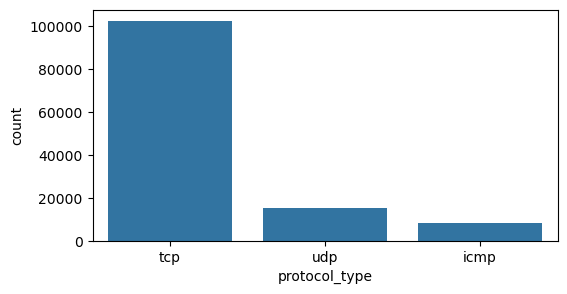

In [19]:
# Protocol type distribution
plt.figure(figsize=(6,3))
sns.countplot(x="protocol_type", data=train)
plt.show()


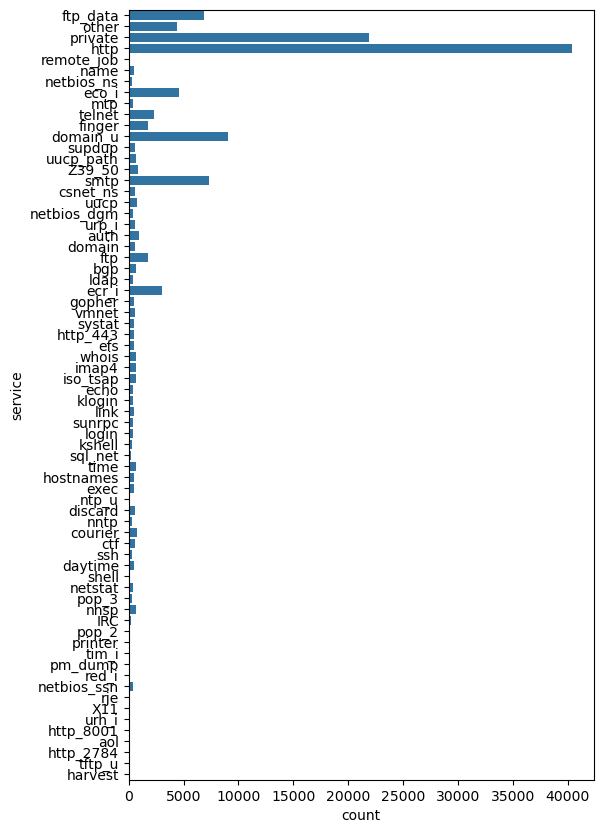

In [20]:
# service distribution
plt.figure(figsize=(6,10))
sns.countplot(y="service", data=train)
plt.show()

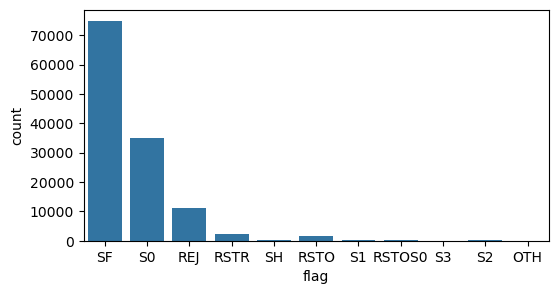

In [21]:
# flag distribution
plt.figure(figsize=(6,3))
sns.countplot(x="flag", data=train)
plt.show()

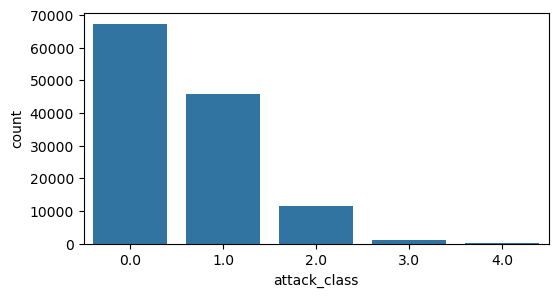

In [22]:
# attack class distribution
plt.figure(figsize=(6,3))
sns.countplot(x="attack_class", data=train)
plt.show()


In [23]:
# Select only numerical columns
numeric_cols = train.select_dtypes(include='number')

# Group by attack_class and calculate mean
mean_values = numeric_cols.groupby(train['attack_class']).mean().T

print(mean_values)


attack_class                          0.0          1.0            2.0  \
duration                       168.587396     0.006227    2074.858185   
src_bytes                    13133.279331  1176.321162  385679.838367   
dst_bytes                     4329.685223   169.201537  181074.911805   
land                             0.000104     0.000392       0.000000   
wrong_fragment                   0.000000     0.062229       0.000000   
urgent                           0.000148     0.000000       0.000000   
hot                              0.230655     0.039889       0.001630   
num_failed_logins                0.001381     0.000000       0.000343   
logged_in                        0.710646     0.020837       0.007121   
num_compromised                  0.507076     0.019226       0.000601   
root_shell                       0.002034     0.000000       0.000000   
su_attempted                     0.002049     0.000000       0.000000   
num_root                         0.562924     0.000

In [24]:
numeric_var_names=[key for key in dict(train.dtypes) if dict(train.dtypes)[key] in ['float64', 'int64', 'float32', 'int32']]
cat_var_names=[key for key in dict(train.dtypes) if dict(train.dtypes)[key] in ['object', 'O']]

In [25]:
numeric_var_names

['duration',
 'src_bytes',
 'dst_bytes',
 'land',
 'wrong_fragment',
 'urgent',
 'hot',
 'num_failed_logins',
 'logged_in',
 'num_compromised',
 'root_shell',
 'su_attempted',
 'num_root',
 'num_file_creations',
 'num_shells',
 'num_access_files',
 'num_outbound_cmds',
 'is_host_login',
 'is_guest_login',
 'count',
 'srv_count',
 'serror_rate',
 'srv_serror_rate',
 'rerror_rate',
 'srv_rerror_rate',
 'same_srv_rate',
 'diff_srv_rate',
 'srv_diff_host_rate',
 'dst_host_count',
 'dst_host_srv_count',
 'dst_host_same_srv_rate',
 'dst_host_diff_srv_rate',
 'dst_host_same_src_port_rate',
 'dst_host_srv_diff_host_rate',
 'dst_host_serror_rate',
 'dst_host_srv_serror_rate',
 'dst_host_rerror_rate',
 'dst_host_srv_rerror_rate',
 'last_flag',
 'attack_class']

In [26]:
cat_var_names

['protocol_type', 'service', 'flag', 'attack']

In [27]:
train_num=train[numeric_var_names]
test_num=test[numeric_var_names]
train_num.head(5)

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,last_flag,attack_class
0,0,491,0,0,0,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,20,0.0
1,0,146,0,0,0,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,15,0.0
2,0,0,0,0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,19,1.0
3,0,232,8153,0,0,0,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,21,0.0
4,0,199,420,0,0,0,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,21,0.0


In [28]:
train_cat=train[cat_var_names]
test_cat=test[cat_var_names]
train_cat.head(5)

,protocol_type,service,flag,attack
0,tcp,ftp_data,SF,normal
1,udp,other,SF,normal
2,tcp,private,S0,neptune
3,tcp,http,SF,normal
4,tcp,http,SF,normal


#Data Audit Report

In [29]:
# Creating Data audit Report
def var_summary(x):
    return pd.Series([x.count(), x.isnull().sum(), x.sum(), x.mean(), x.median(),  x.std(), x.var(), x.min(), x.dropna().quantile(0.01), x.dropna().quantile(0.05),x.dropna().quantile(0.10),x.dropna().quantile(0.25),x.dropna().quantile(0.50),x.dropna().quantile(0.75), x.dropna().quantile(0.90),x.dropna().quantile(0.95), x.dropna().quantile(0.99),x.max()], 
                  index=['N', 'NMISS', 'SUM', 'MEAN','MEDIAN', 'STD', 'VAR', 'MIN', 'P1' , 'P5' ,'P10' ,'P25' ,'P50' ,'P75' ,'P90' ,'P95' ,'P99' ,'MAX'])

num_summary=train_num.apply(lambda x: var_summary(x)).T

In [30]:
num_summary

,N,NMISS,SUM,MEAN,MEDIAN,STD,VAR,MIN,P1,P5,P10,P25,P50,P75,P90,P95,P99,MAX
duration,125973.0,0.0,3.617247e+07,287.144650,0.00,2.604515e+03,6.783500e+06,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,4.00,9590.56,4.290800e+04
src_bytes,125973.0,0.0,5.740179e+09,45566.743000,44.00,5.870331e+06,3.446079e+13,0.0,0.0,0.00,0.00,0.00,44.00,276.00,848.00,1480.00,54540.00,1.379964e+09
dst_bytes,125973.0,0.0,2.491634e+09,19779.114421,0.00,4.021269e+06,1.617061e+13,0.0,0.0,0.00,0.00,0.00,0.00,516.00,3375.80,8314.00,25519.00,1.309937e+09
land,125973.0,0.0,2.500000e+01,0.000198,0.00,1.408607e-02,1.984174e-04,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125973.0,0.0,2.858000e+03,0.022687,0.00,2.535300e-01,6.427745e-02,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.000000e+00
urgent,125973.0,0.0,1.400000e+01,0.000111,0.00,1.436603e-02,2.063827e-04,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.000000e+00
hot,125973.0,0.0,2.575000e+04,0.204409,0.00,2.149968e+00,4.622364e+00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,7.700000e+01
num_failed_logins,125973.0,0.0,1.540000e+02,0.001222,0.00,4.523914e-02,2.046580e-03,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.000000e+00
logged_in,125973.0,0.0,4.985200e+04,0.395736,0.00,4.890101e-01,2.391308e-01,0.0,0.0,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.000000e+00
num_compromised,125973.0,0.0,3.517800e+04,0.279250,0.00,2.394204e+01,5.732214e+02,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,7.479000e+03


In [31]:
num_summary.to_csv('num_summary.csv')

In [32]:
#Handling Outlier

In [33]:
#Handling Outliers
def outlier_capping(x):
    x = x.clip(upper=x.quantile(0.99))
    x = x.clip(lower=x.quantile(0.01))
    return x

train_num=train_num.apply(outlier_capping)

In [34]:
#No missing in train dataset . So , Missing treatment not required .

In [35]:
def cat_summary(x):
    return pd.Series([x.count(), x.isnull().sum(), x.value_counts()], 
                  index=['N', 'NMISS', 'ColumnsNames'])

cat_summary=train_cat.apply(cat_summary)

In [36]:
cat_summary

,protocol_type,service,flag,attack
N,125973,125973,125973,125973
NMISS,0,0,0,0
ColumnsNames,protocol_type tcp 102689 udp 14993 ic...,service http 40338 private 21853 ...,flag SF 74945 S0 34851 REJ ...,attack normal 67343 neptune ...


In [37]:
#Dummy Variable Creation

In [38]:
# An utility function to create dummy variable
def create_dummies( df, colname ):
    col_dummies = pd.get_dummies(df[colname], prefix=colname, drop_first=True)
    df = pd.concat([df, col_dummies], axis=1)
    df.drop( colname, axis = 1, inplace = True )
    return(df)

In [39]:
#for c_feature in categorical_features
for c_feature in ['protocol_type', 'service', 'flag', 'attack']:
    train_cat = create_dummies(train_cat,c_feature)
    test_cat = create_dummies(test_cat,c_feature)
train_cat.head()

,protocol_type_tcp,protocol_type_udp,service_X11,service_Z39_50,service_aol,service_auth,service_bgp,service_courier,service_csnet_ns,service_ctf,...,attack_phf,attack_pod,attack_portsweep,attack_rootkit,attack_satan,attack_smurf,attack_spy,attack_teardrop,attack_warezclient,attack_warezmaster
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [40]:
#Final file for analysis
train_new = pd.concat([train_num, train_cat], axis=1)
test_new = pd.concat([test_num, test_cat], axis=1)
train_new.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,attack_phf,attack_pod,attack_portsweep,attack_rootkit,attack_satan,attack_smurf,attack_spy,attack_teardrop,attack_warezclient,attack_warezmaster
0,0.0,491,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,0.0,146,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,0.0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,0.0,232,8153,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,False,False
4,0.0,199,420,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,False,False


In [41]:
# correlation matrix (ranges from 1 to -1)
corrm=train_new.corr()
corrm

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,attack_phf,attack_pod,attack_portsweep,attack_rootkit,attack_satan,attack_smurf,attack_spy,attack_teardrop,attack_warezclient,attack_warezmaster
duration,1.000000,0.011740,0.036892,NaN,NaN,NaN,0.021274,NaN,-0.064537,0.062081,...,-0.000757,-0.005534,0.408874,-0.000414,-0.023837,-0.020278,0.000605,-0.011691,0.037014,-0.001571
src_bytes,0.011740,1.000000,0.127827,NaN,NaN,NaN,0.379973,NaN,0.163275,0.603363,...,-0.000898,0.002845,-0.022114,-0.001067,-0.028784,-0.002928,-0.000555,-0.013779,0.047995,-0.002012
dst_bytes,0.036892,0.127827,1.000000,NaN,NaN,NaN,0.127002,NaN,0.422000,0.237363,...,0.010050,-0.014103,-0.053376,0.006873,-0.060373,-0.051675,-0.000156,-0.029791,-0.011541,0.064962
land,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wrong_fragment,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
attack_smurf,-0.020278,-0.002928,-0.051675,NaN,NaN,NaN,-0.020616,NaN,-0.118537,-0.014876,...,-0.000825,-0.005856,-0.022607,-0.001305,-0.025241,1.000000,-0.000584,-0.012370,-0.012356,-0.001846
attack_spy,0.000605,-0.000555,-0.000156,NaN,NaN,NaN,-0.000561,NaN,0.000850,-0.000405,...,-0.000022,-0.000159,-0.000615,-0.000036,-0.000687,-0.000584,1.000000,-0.000336,-0.000336,-0.000050
attack_teardrop,-0.011691,-0.013779,-0.029791,NaN,NaN,NaN,-0.011886,NaN,-0.068340,-0.008576,...,-0.000476,-0.003376,-0.013034,-0.000752,-0.014552,-0.012370,-0.000336,1.000000,-0.007123,-0.001064
attack_warezclient,0.037014,0.047995,-0.011541,NaN,NaN,NaN,0.270177,NaN,0.104233,-0.008567,...,-0.000475,-0.003372,-0.013019,-0.000752,-0.014536,-0.012356,-0.000336,-0.007123,1.000000,-0.001063


In [42]:
corrm.to_csv('corrm.csv')

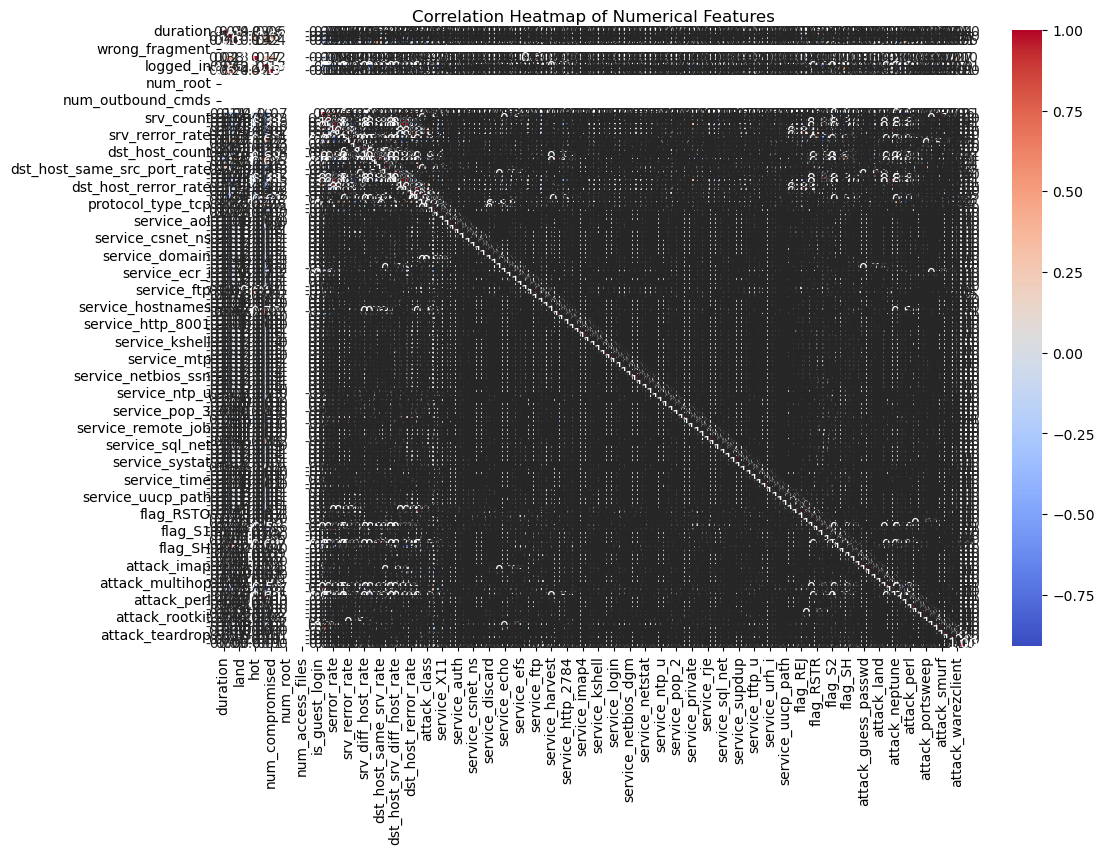

In [43]:
# visualize correlation matrix in Seaborn using a heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corrm, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()
 

#Dropping columns based on data audit report
    - Based on low variance (near zero variance)
    - High missings (>25% missings)
    - High correlations between two numerical variables

In [44]:
train_new.drop(columns=['land','wrong_fragment','urgent','num_failed_logins',"root_shell","su_attempted","num_root",
                        "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
                        'dst_host_rerror_rate','dst_host_serror_rate','dst_host_srv_rerror_rate','dst_host_srv_serror_rate',
                        'num_root','num_outbound_cmds','srv_rerror_rate','srv_serror_rate'], axis=1, inplace=True)

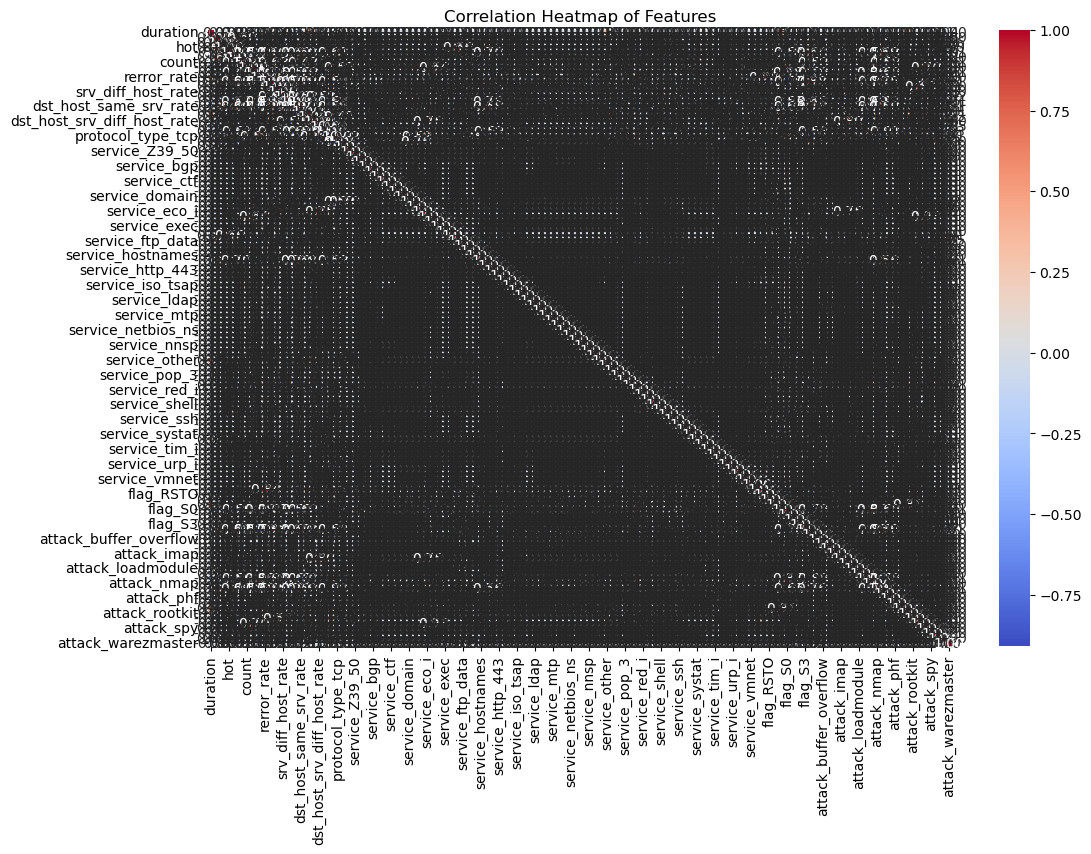

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(train_new.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Features")
plt.show()


In [46]:
#Variable reduction using Select K-Best technique

In [47]:
X = train_new[train_new.columns.difference(['attack_class'])]
X_new = SelectKBest(f_classif, k=15).fit(X, train_new['attack_class'] )

D:\mca program\New folder\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


In [48]:
X_new.get_support()

array([False, False, False, False, False, False, False, False,  True,
       False,  True, False, False, False, False, False,  True, False,
       False, False, False, False,  True, False, False, False,  True,
        True,  True,  True, False, False, False, False, False, False,
        True, False, False, False,  True, False, False,  True,  True,
       False, False, False, False,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False])

In [49]:
X_new.scores_

array([1.34065299e+02, 3.56887917e+01, 2.37279329e+02, 4.90836877e+01,
       2.23884568e+04, 1.56918435e+01, 4.01530535e+01, 3.12252331e+01,
       3.49982737e+05, 7.54273339e+03,            inf, 1.33780279e+01,
       1.78387751e+01, 1.75926856e+02, 1.69866181e+04, 4.46180188e+01,
       2.26846808e+04, 2.44676269e+03, 8.91798303e+00, 7.92709355e+02,
       4.26682042e+03, 8.93063964e+01, 4.22705436e+04, 7.97243466e+03,
       5.76288566e+03, 1.85805841e+04, 2.24897554e+04, 2.75243035e+04,
       6.70289217e+04, 6.92391745e+04, 1.83321617e+04, 2.42925483e+03,
       2.92640418e+03, 6.10534447e+02, 4.62957625e+02, 1.01592923e+04,
       1.10261782e+05, 1.52319746e+02, 4.14800692e+01, 1.57818504e+01,
       1.10778397e+05, 1.21396798e+03, 1.29056823e+02, 3.23688064e+04,
       5.75742500e+04, 2.97257109e+02, 5.23057861e+03, 3.77788086e+03,
       8.06842874e+03, 1.33881495e+05, 1.02835005e+05, 2.34821159e+01,
       7.35347601e+02, 8.91798303e+00, 2.91634092e+02, 5.98598479e+02,
      

In [50]:
# capturing the important variables
KBest_features=X.columns[X_new.get_support()]
KBest_features

Index(['attack_neptune', 'attack_normal', 'attack_satan', 'count',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_same_srv_rate', 'dst_host_srv_count', 'flag_S0', 'flag_SF',
       'last_flag', 'logged_in', 'same_srv_rate', 'serror_rate',
       'service_http'],
      dtype='object')

In [51]:
train=train_new
test=test_new

In [52]:
# Model Building nids

In [53]:
top_features=['attack_neptune','attack_normal','attack_satan','count','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_same_srv_rate','dst_host_srv_count','flag_S0','flag_SF','last_flag','logged_in','same_srv_rate','serror_rate','service_http']
X_train = train[top_features]
y_train = train['attack_class']
X_test = test[top_features]
y_test = test['attack_class']

In [54]:
# Building logistic Regression

In [55]:
import warnings
warnings.filterwarnings('ignore')
lr_clf = LogisticRegression(random_state=0, solver='lbfgs',multi_class='multinomial').fit(X_train, y_train)

In [56]:
y_pred=lr_clf.predict(X_test)
y_pred

array([1., 1., 0., ..., 1., 0., 2.])

In [57]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8364975159687722

In [58]:
# RidgeClassifier

In [59]:
from sklearn.linear_model import RidgeClassifier

In [60]:
rc_clf = RidgeClassifier().fit(X_train, y_train)

In [61]:
y_pred=rc_clf.predict(X_test)
y_pred

array([1., 1., 0., ..., 2., 0., 2.])

In [62]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)


0.7606014904187367

In [63]:
# K-Nearest Neighbors

In [64]:
from sklearn.neighbors import KNeighborsClassifier

In [65]:
k_neigh = KNeighborsClassifier(n_neighbors=3)
k_neigh.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [66]:
y_pred=k_neigh.predict(X_test)
y_pred

array([1., 1., 0., ..., 1., 0., 0.])

In [67]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)


0.7539921930447125

In [68]:
# NearestCentroid

In [69]:
from sklearn.neighbors import NearestCentroid


In [70]:
nc = NearestCentroid()
nc.fit(X_train, y_train)

NearestCentroid()

In [71]:
y_pred=nc.predict(X_test)
y_pred

array([1., 1., 2., ..., 0., 0., 2.])

In [72]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.6059261887863733

In [73]:
#Discriminant Analysis

In [74]:
#1) LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [75]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train) 

LinearDiscriminantAnalysis()

In [76]:
y_pred=lda.predict(X_test)
y_pred

array([1., 1., 0., ..., 0., 0., 2.])

In [77]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.7071504613200852

In [78]:
#2) QuadraticDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

In [79]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

QuadraticDiscriminantAnalysis()

In [80]:
y_pred=qda.predict(X_test)
y_pred

array([0., 0., 0., ..., 0., 0., 0.])

In [81]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.43075762952448543

In [82]:
# Decision Trees Algorithm

In [83]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.model_selection import GridSearchCV
from sklearn import metrics


In [84]:
clf_tree = DecisionTreeClassifier( max_depth = 5)
clf_tree=clf_tree.fit( X_train, y_train )

In [85]:
y_pred=qda.predict(X_test)
y_pred

array([0., 0., 0., ..., 0., 0., 0.])

In [86]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.43075762952448543

In [87]:
#Fine Tuning the parameters

In [88]:
param_grid = {'max_depth': np.arange(3, 9),
             'max_features': np.arange(3,9)}

In [89]:
tree = GridSearchCV(DecisionTreeClassifier(), param_grid, cv = 5)
tree.fit( X_train, y_train )

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': array([3, 4, 5, 6, 7, 8]),
                         'max_features': array([3, 4, 5, 6, 7, 8])})

In [90]:
tree.best_score_

np.float64(0.9978884434679328)

In [91]:
tree.best_estimator_

DecisionTreeClassifier(max_depth=np.int64(7), max_features=np.int64(7))

In [92]:
tree.best_params_

{'max_depth': np.int64(7), 'max_features': np.int64(7)}

In [93]:
#Building Final Decision Tree Model

In [94]:
clf_tree = DecisionTreeClassifier( max_depth = 8, max_features=8 )
clf_tree.fit( X_train, y_train)

DecisionTreeClassifier(max_depth=8, max_features=8)

In [95]:
#Feature Relative Importance
clf_tree.feature_importances_

array([1.81933139e-01, 7.26912101e-01, 1.17172277e-02, 4.64153875e-02,
       6.10895550e-03, 1.13916395e-03, 1.97563733e-03, 2.09513374e-02,
       3.46817335e-04, 3.27983026e-04, 8.61776226e-04, 5.52181000e-05,
       7.61889506e-05, 5.40467896e-05, 1.12502039e-03])

In [96]:
# summarize the selection of the attributes
import itertools
feature_map = [(i, v) for i, v in itertools.zip_longest(X_train.columns, clf_tree.feature_importances_)]

feature_map

[('attack_neptune', np.float64(0.18193313904044958)),
 ('attack_normal', np.float64(0.7269121008200662)),
 ('attack_satan', np.float64(0.011717227708442282)),
 ('count', np.float64(0.046415387460543994)),
 ('dst_host_diff_srv_rate', np.float64(0.006108955499726172)),
 ('dst_host_same_src_port_rate', np.float64(0.001139163946522893)),
 ('dst_host_same_srv_rate', np.float64(0.001975637332947397)),
 ('dst_host_srv_count', np.float64(0.020951337370477142)),
 ('flag_S0', np.float64(0.0003468173350143626)),
 ('flag_SF', np.float64(0.00032798302617426144)),
 ('last_flag', np.float64(0.0008617762258468671)),
 ('logged_in', np.float64(5.5218099985535306e-05)),
 ('same_srv_rate', np.float64(7.618895064169786e-05)),
 ('serror_rate', np.float64(5.404678960157213e-05)),
 ('service_http', np.float64(0.0011250203935599839))]

In [97]:
Feature_importance = pd.DataFrame(feature_map, columns=['Feature', 'importance'])
Feature_importance.sort_values('importance', inplace=True, ascending=False)
Feature_importance

,Feature,importance
1,attack_normal,0.726912
0,attack_neptune,0.181933
3,count,0.046415
7,dst_host_srv_count,0.020951
2,attack_satan,0.011717
4,dst_host_diff_srv_rate,0.006109
6,dst_host_same_srv_rate,0.001976
5,dst_host_same_src_port_rate,0.001139
14,service_http,0.001125
10,last_flag,0.000862


In [98]:
tree_test_pred = pd.DataFrame( { 'actual':  y_test,
                            'predicted': clf_tree.predict( X_test ) } )

In [99]:
tree_test_pred.sample( n = 10 )

,actual,predicted
3436,3.0,2.0
9244,3.0,2.0
16986,0.0,0.0
20502,1.0,1.0
20577,0.0,0.0
5486,1.0,1.0
4420,0.0,0.0
11633,1.0,1.0
5061,1.0,1.0
17672,1.0,1.0


In [100]:
accuracy_score( tree_test_pred.actual, tree_test_pred.predicted )

0.8100603264726757

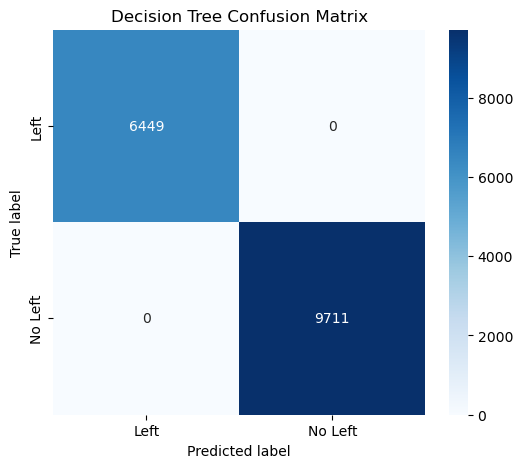

In [101]:
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
tree_cm = metrics.confusion_matrix(
    y_true=tree_test_pred.actual,
    y_pred=tree_test_pred.predicted,
    labels=[1, 0]  # must be keyword
)

# Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(tree_cm, annot=True, fmt='d', 
            xticklabels=["Left", "No Left"], 
            yticklabels=["Left", "No Left"], cmap='Blues')

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title("Decision Tree Confusion Matrix")
plt.show()


In [102]:
#Naive Bayes Model

In [103]:
from sklearn.naive_bayes import BernoulliNB

In [104]:
bnb_clf = BernoulliNB()
bnb_clf.fit(X_train, y_train)

BernoulliNB()

In [105]:
y_pred=bnb_clf.predict(X_test)
y_pred

array([1., 1., 0., ..., 0., 0., 2.])

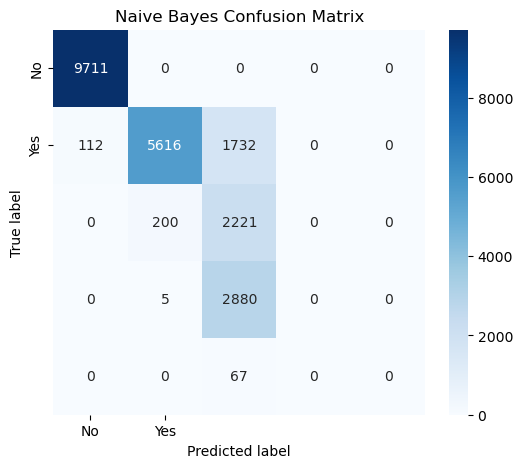

In [106]:
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
nb_cm = metrics.confusion_matrix(y_test, y_pred)

# Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(nb_cm, annot=True, fmt='d',  # use 'd' for integer counts
            xticklabels=["No", "Yes"], 
            yticklabels=["No", "Yes"], cmap='Blues')

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title("Naive Bayes Confusion Matrix")
plt.show()


In [107]:
 accuracy_score( y_test, y_pred )

0.778388928317956

In [108]:
#2) GaussianNB
from sklearn.naive_bayes import GaussianNB

In [109]:
gnb_clf = GaussianNB()
gnb_clf.fit(X_train, y_train)

GaussianNB()

In [110]:
y_pred=gnb_clf.predict(X_test)
y_pred

array([1., 1., 0., ..., 1., 0., 2.])

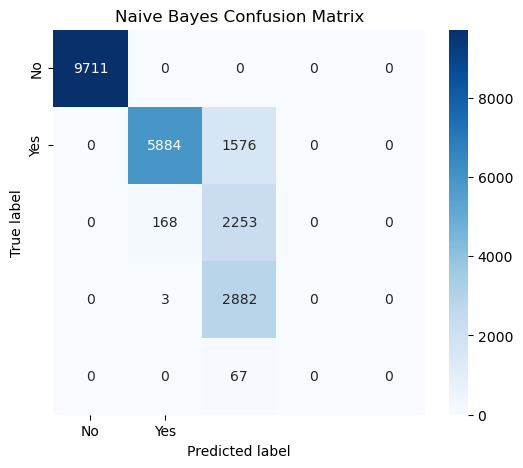

In [111]:
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
nb_cm = metrics.confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(nb_cm, annot=True, fmt='d',  # use 'd' for integers
            xticklabels=["No", "Yes"], 
            yticklabels=["No", "Yes"], cmap='Blues')

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title("Naive Bayes Confusion Matrix")
plt.show()


In [112]:
accuracy_score( y_test, y_pred )

0.7916962384669979

In [113]:
 #Support Vector Machine (SVM)

In [114]:
#1) LinearSVC
from sklearn.svm import LinearSVC

In [115]:
svm_clf = LinearSVC(random_state=0, tol=1e-5)
svm_clf.fit(X_train, y_train)

LinearSVC(random_state=0, tol=1e-05)

In [116]:
y_pred=svm_clf.predict(X_test)
y_pred

array([1., 1., 0., ..., 1., 0., 2.])

In [117]:
accuracy_score( y_test, y_pred )

0.8371185237757275

In [118]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [119]:
model = SGDClassifier(loss="hinge", penalty="l2")
model.fit(X_train, y_train)

SGDClassifier()

In [120]:
y_pred=model.predict(X_test)
y_pred

array([1., 1., 0., ..., 1., 0., 2.])

In [121]:
accuracy_score( y_test, y_pred )

0.7959102200141944

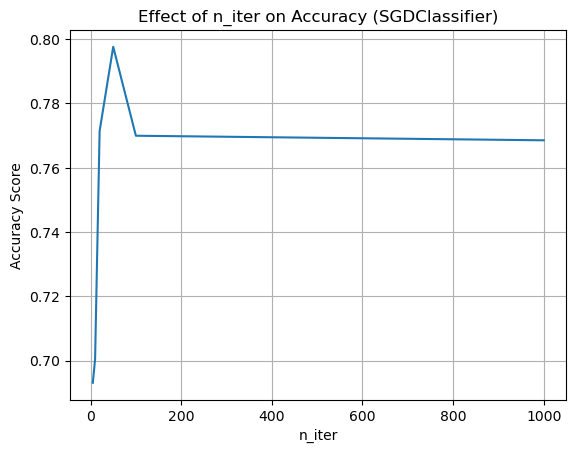

In [122]:
 #  List of different iteration counts
n_iters = [5, 10, 20, 50, 100, 1000]
scores = []

# Train model with different n_iter values
for n_iter in n_iters:
    model = SGDClassifier(loss="hinge", penalty="l2", max_iter=n_iter)
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

# Plot results
plt.title("Effect of n_iter on Accuracy (SGDClassifier)")
plt.xlabel("n_iter")
plt.ylabel("Accuracy Score")
plt.plot(n_iters, scores)
plt.grid()       # optional, to make graph clearer
plt.show()


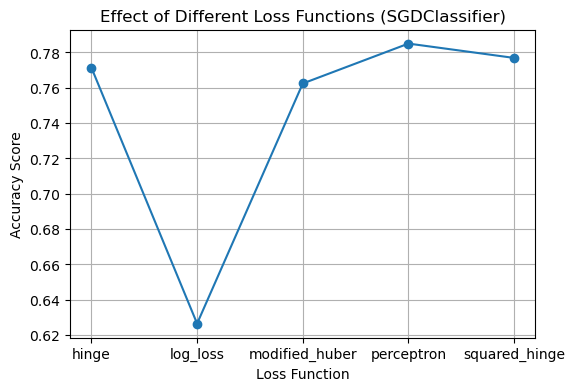

In [123]:
#Different loss functions to compare
losses = ["hinge", "log_loss", "modified_huber", "perceptron", "squared_hinge"]
scores = []

for loss in losses:
    model = SGDClassifier(loss=loss, penalty="l2", max_iter=1000)
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

#  Plot
plt.figure(figsize=(6,4))
plt.xlabel("Loss Function")
plt.ylabel("Accuracy Score")
plt.title("Effect of Different Loss Functions (SGDClassifier)")
x = np.arange(len(losses))
plt.xticks(x, losses)
plt.plot(x, scores, marker='o')  # marker added to show points
plt.grid()
plt.show()


In [124]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
scaler = StandardScaler()
# Fit only to the training data
scaler.fit(X_train)

StandardScaler()

In [125]:
# Now apply the transformations to the data:
train_X = scaler.transform(X_train)
test_X = scaler.transform(X_test)

In [126]:
mlp = MLPClassifier(hidden_layer_sizes=(30,30,30))
mlp.fit(train_X,y_train)

MLPClassifier(hidden_layer_sizes=(30, 30, 30))

In [127]:
y_pred=mlp.predict(test_X)
y_pred

array([1., 1., 0., ..., 1., 0., 2.])

In [128]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred))

[[9711    0    0    0    0]
 [   0 6845  615    0    0]
 [   0  319 2102    0    0]
 [ 309  406 2170    0    0]
 [   0    0   67    0    0]]


In [129]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98      9711
         1.0       0.90      0.92      0.91      7460
         2.0       0.42      0.87      0.57      2421
         3.0       0.00      0.00      0.00      2885
         4.0       0.00      0.00      0.00        67

    accuracy                           0.83     22544
   macro avg       0.46      0.56      0.49     22544
weighted avg       0.76      0.83      0.79     22544



In [130]:
mlp.coefs_

[array([[ 7.76973372e-01, -2.85651124e-01, -3.85775403e-01,
          3.87945159e-01, -2.45822784e-01,  3.25552961e-01,
         -9.50645614e-02, -6.30125950e-02,  1.00229408e-01,
          3.28190048e-01,  4.26955861e-02, -1.06369637e-01,
          5.87220085e-01, -4.56031628e-01, -4.71673353e-02,
          6.67755814e-02, -4.10080611e-01, -1.90899778e-01,
          3.07216716e-01, -8.29434587e-02,  4.82712819e-01,
         -1.40429022e-02,  1.90589526e-01, -1.66510014e-01,
          3.10376390e-01,  1.47160505e-01, -5.22092427e-01,
         -2.85401495e-01,  2.65043967e-01, -2.58758573e-02],
        [ 1.14796357e-01,  5.61738386e-02,  9.96542795e-02,
         -2.25869165e-01,  6.95261478e-02,  8.82162702e-02,
          7.59512692e-01, -4.57900107e-03,  6.22704265e-01,
         -3.50145133e-02, -5.08871211e-01,  6.10208195e-02,
         -3.15646681e-01, -6.24956289e-02,  2.20529503e-02,
          1.86352687e-01,  1.85547411e-01, -7.94480728e-02,
         -5.05480688e-01,  9.70310600e-

In [131]:
#1. Bagged Decision Trees
from sklearn import model_selection
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

In [132]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
import numpy as np

seed = 7
kfold = KFold(n_splits=10, shuffle=True, random_state=seed)

cart = DecisionTreeClassifier()
num_trees = 100

model = BaggingClassifier(
    estimator=cart,          #  replaced base_estimator with estimator
    n_estimators=num_trees,
    random_state=seed
)

results = cross_val_score(model, X_train, y_train, cv=kfold)
print("Average Accuracy:", results.mean())
print("All CV scores:", results)


Average Accuracy: 0.9993570048826251
All CV scores: [0.99960311 0.9992856  0.99920622 0.99960308 0.99944431 0.99928554
 0.99976185 0.99920616 0.99872986 0.99944431]


In [133]:
model.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                  random_state=7)

In [134]:
y_pred=model.predict(X_test)
y_pred

array([1., 1., 0., ..., 1., 0., 2.])

In [135]:
accuracy_score( y_test, y_pred )

0.8117459190915542

In [136]:
#2)Random forest

In [137]:
from sklearn.ensemble import RandomForestClassifier

In [138]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

seed = 7
num_trees = 100
max_features = 3

kfold = KFold(n_splits=10, shuffle=True, random_state=seed)

model = RandomForestClassifier(
    n_estimators=num_trees,
    max_features=max_features,
    random_state=seed
)

results = cross_val_score(model, X_train, y_train, cv=kfold)
print("Average Accuracy:", results.mean())
print("All Fold Scores:", results)


Average Accuracy: 0.9994998928965302
All Fold Scores: [0.99960311 0.99952373 0.99936498 0.99960308 0.99936493 0.99944431
 0.99984123 0.99944431 0.99928554 0.9995237 ]


In [139]:
model.fit(X_train, y_train)


RandomForestClassifier(max_features=3, random_state=7)

In [140]:
y_pred=model.predict(X_test)
y_pred

array([1., 1., 0., ..., 1., 0., 2.])

In [141]:
accuracy_score( y_test, y_pred )


0.8183995741660752

In [142]:
#3. Extra Trees
from sklearn.ensemble import ExtraTreesClassifier

In [143]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import ExtraTreesClassifier
import warnings
warnings.filterwarnings("ignore")

seed = 7
num_trees = 100
max_features = 7

# Shuffle=True avoids warnings & gives better folds
kfold = KFold(n_splits=10, shuffle=True, random_state=seed)

model = ExtraTreesClassifier(
    n_estimators=num_trees,
    max_features=max_features,
    random_state=seed,
    class_weight='balanced'
)

results = cross_val_score(model, X_train, y_train, cv=kfold)
print("Average Accuracy:", results.mean())
print("All Fold Scores:", results)


Average Accuracy: 0.9994919538683673
All Fold Scores: [0.99944436 0.99968249 0.99944436 0.99936493 0.99928554 0.99920616
 0.99968246 0.99960308 0.99960308 0.99960308]


In [144]:
model.fit(X_train, y_train)

ExtraTreesClassifier(class_weight='balanced', max_features=7, random_state=7)

In [145]:
y_pred=model.predict(X_test)
y_pred

array([1., 1., 0., ..., 1., 0., 2.])

In [146]:
accuracy_score( y_test, y_pred )

0.8038502484031228

In [147]:
#Boosting Algorithms

In [148]:
#. AdaBoost
from sklearn.ensemble import AdaBoostClassifier

In [149]:
from sklearn import model_selection
from sklearn.ensemble import AdaBoostClassifier

seed = 7
num_trees = 30

kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=seed)
model = AdaBoostClassifier(n_estimators=num_trees, random_state=seed)

results = model_selection.cross_val_score(model, X_train, y_train, cv=kfold)
print("AdaBoost Accuracy (10-Fold):", results.mean())


AdaBoost Accuracy (10-Fold): 0.9954196451570108


In [150]:
model.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=30, random_state=7)

In [151]:
y_pred=model.predict(X_test)
y_pred

array([1., 1., 0., ..., 1., 0., 2.])

In [152]:
accuracy_score( y_test, y_pred )

0.8156937544357701

In [153]:
#Save Model

In [154]:
import pickle
# Saving model to disk of random forest
pickle.dump(lr_clf, open('model1.pkl','wb'))

In [155]:
#Load Model and Predict

In [156]:
import pickle
model=pickle.load(open('model1.pkl', 'rb'))
model.predict([[1,0,0,229,0.06,0.00,0.04,10,0,0,21,0,0.04,0.00,0]])

array([1.])

In [157]:
# ---------------- SYSTEM ----------------
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"

import warnings
warnings.filterwarnings("ignore")

# ---------------- IMPORTS ----------------
import pandas as pd
import numpy as np
import joblib

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from collections import Counter

# ---------------- COMMON ----------------
columns = [f"f{i}" for i in range(41)] + ["label", "difficulty"]

def clean(y):
    return y.astype(str).str.strip().str.replace(r'\.$', '', regex=True).str.lower()

attack_map = {
    'normal': 0,
    'neptune': 1, 'smurf': 1, 'back': 1, 'teardrop': 1, 'pod': 1, 'land': 1,
    'ipsweep': 2, 'nmap': 2, 'portsweep': 2, 'satan': 2,
    'ftp_write': 3, 'guess_passwd': 3, 'imap': 3, 'multihop': 3,
    'phf': 3, 'spy': 3, 'warezclient': 3, 'warezmaster': 3,
    'buffer_overflow': 4, 'loadmodule': 4, 'perl': 4, 'rootkit': 4
}

# ---------------- LOAD TRAIN ----------------
train_df = pd.read_csv("KDDTrain.csv", header=None)
train_df.columns = columns
train_df.drop("difficulty", axis=1, inplace=True)
train_df = train_df.replace([np.inf, -np.inf], np.nan).fillna(0)

X = train_df.drop("label", axis=1)
y = clean(train_df["label"]).map(attack_map)

mask = y.notnull()
X, y = X[mask], y[mask].astype(int)

# ---------------- ENCODING ----------------
categorical_cols = ["f1", "f2", "f3"]
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

# ---------------- SPLIT ----------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ---------------- SCALING ----------------
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# ---------------- BALANCING (BEST FIX) ----------------
print("Before balance:", Counter(y_train))

smote = SMOTE(random_state=42, k_neighbors=3)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After balance:", Counter(y_train))

# ---------------- CLASS WEIGHTS ----------------
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

weight_dict = {i: w for i, w in enumerate(class_weights)}
sample_weights = np.array([weight_dict[y] for y in y_train])

# ---------------- MODEL (FINAL XGBOOST) ----------------
model = XGBClassifier(
    n_estimators=350,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.6,
    reg_lambda=2.5,
    gamma=0.1,
    min_child_weight=2,
    objective="multi:softprob",
    num_class=5,
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=4
)

print("🚀 Training Advanced XGBoost...")
model.fit(X_train, y_train, sample_weight=sample_weights)

# ---------------- VALIDATION ----------------
val_probs = model.predict_proba(X_val)
y_val_pred = np.argmax(val_probs, axis=1)

print("\n📊 VALIDATION")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

# ---------------- LOAD TEST ----------------
test_df = pd.read_csv("KDDTest.csv", header=None)
test_df.columns = columns
test_df.drop("difficulty", axis=1, inplace=True)
test_df = test_df.replace([np.inf, -np.inf], np.nan).fillna(0)

X_test = test_df.drop("label", axis=1)
y_test = clean(test_df["label"]).map(attack_map)

mask = y_test.notnull()
X_test, y_test = X_test[mask], y_test[mask].astype(int)

# ---------------- ENCODE TEST ----------------
for col, enc in encoders.items():
    X_test[col] = X_test[col].astype(str)
    X_test[col] = X_test[col].apply(
        lambda x: x if x in enc.classes_ else enc.classes_[0]
    )
    X_test[col] = enc.transform(X_test[col])

# ---------------- SCALE TEST ----------------
X_test = scaler.transform(X_test)

# ---------------- TEST PREDICT ----------------
test_probs = model.predict_proba(X_test)
y_test_pred = np.argmax(test_probs, axis=1)

print("\n🔥 TEST")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))
print("Distribution:", Counter(y_test_pred))

# ---------------- SAVE ----------------
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoders, "encoders.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

print("\n✅ FINAL MODEL SAVED SUCCESSFULLY")

Before balance: Counter({0: 53874, 1: 36741, 2: 9325, 3: 796, 4: 42})
After balance: Counter({1: 53874, 0: 53874, 2: 53874, 3: 53874, 4: 53874})
🚀 Training Advanced XGBoost...

📊 VALIDATION
Accuracy: 0.9990871204604088
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00      9186
           2       1.00      1.00      1.00      2331
           3       0.98      0.98      0.98       199
           4       0.82      0.90      0.86        10

    accuracy                           1.00     25195
   macro avg       0.96      0.98      0.97     25195
weighted avg       1.00      1.00      1.00     25195


🔥 TEST
Accuracy: 0.880227732254975
              precision    recall  f1-score   support

           0       0.84      0.97      0.90      9711
           1       0.99      0.99      0.99      5741
           2       0.77      1.00      0.87      1106
           3       0.99      0.14      

In [ ]:
# ---------------- IMPORTS ----------------
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
import xgboost as xgb


# ---------------- LOAD DATA ----------------
train = pd.read_csv("KDDTrain.csv")
test = pd.read_csv("KDDTest.csv")

# FIX column mismatch
test.columns = train.columns


# ---------------- ATTACK LABEL FIX ----------------
def map_attack(label):
    if label == "normal":
        return 0
    elif label in ["neptune","smurf","back","teardrop","pod","land"]:
        return 1
    elif label in ["satan","ipsweep","nmap","portsweep"]:
        return 2
    elif label in ["guess_passwd","ftp_write","imap","phf","multihop","warezmaster","warezclient"]:
        return 3
    else:
        return 4

train.iloc[:, -1] = train.iloc[:, -1].apply(map_attack)
test.iloc[:, -1] = test.iloc[:, -1].apply(map_attack)


# ---------------- ENCODING (FIXED) ----------------
categorical_cols = train.select_dtypes(include='object').columns
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    encoders[col] = le

for col in categorical_cols:
    le = encoders[col]
    test[col] = test[col].map(lambda x: x if x in le.classes_ else le.classes_[0])
    test[col] = le.transform(test[col])


# ---------------- SPLIT ----------------
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]


# ---------------- SMOTE ----------------
print("\nBefore SMOTE:\n", y_train.value_counts())

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:\n", pd.Series(y_train).value_counts())


# ---------------- SCALING ----------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ---------------- MODELS ----------------
models = {
    "XGBoost": xgb.XGBClassifier(eval_metric='mlogloss', use_label_encoder=False, n_estimators=100),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(kernel='rbf')
}


# ---------------- TRAIN + EVALUATE ----------------
results = []

for name, model in models.items():
    print("\n====================================")
    print("🚀 Training:", name)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1 Score :", round(f1, 4))

    results.append([name, acc, prec, rec, f1])


# ---------------- FINAL RESULT ----------------
results_df = pd.DataFrame(results, columns=[
    "Algorithm", "Accuracy", "Precision", "Recall", "F1 Score"
])

print("\n================ FINAL COMPARISON ================\n")
print(results_df.sort_values(by="Accuracy", ascending=False).to_string(index=False))


# ---------------- BEST MODEL ----------------
best_model_name = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Algorithm"]

print("\n BEST MODEL:", best_model_name)

best_model = models[best_model_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("\n📄 CLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_pred))


# ---------------- SAVE ----------------
results_df.to_csv("model_results.csv", index=False)
print("\n✅ Saved: model_results.csv")

Before SMOTE: 42
21    62557
18    20667
20    19339
19    10284
15     3990
17     3074
16     2393
12      729
14      674
11      641
13      451
10      253
9       194
7       118
8       106
6        96
5        81
4        79
0        66
3        65
1        62
2        54
Name: count, dtype: int64
After SMOTE: 42
20    62557
15    62557
0     62557
6     62557
1     62557
5     62557
3     62557
7     62557
8     62557
9     62557
10    62557
13    62557
2     62557
11    62557
14    62557
12    62557
16    62557
17    62557
18    62557
21    62557
19    62557
4     62557
Name: count, dtype: int64

🚀 Training XGBoost...
Accuracy: 0.4826
Precision: 0.5868
Recall: 0.4826
F1 Score: 0.5230

🚀 Training Random Forest...


Before balance: Counter({0: 53874, 1: 36741, 2: 9325, 3: 796, 4: 42})
After balance: Counter({0: 53874, 1: 36741, 2: 9325, 3: 4000, 4: 2000})
🚀 Training XGBoost...

📊 VALIDATION
Accuracy: 0.9984520738241714
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00      9186
           2       1.00      1.00      1.00      2331
           3       0.92      0.99      0.96       199
           4       0.47      0.90      0.62        10

    accuracy                           1.00     25195
   macro avg       0.88      0.98      0.91     25195
weighted avg       1.00      1.00      1.00     25195


🔥 TEST
Accuracy: 0.8966159412578483
              precision    recall  f1-score   support

           0       0.85      0.97      0.91      9711
           1       0.99      0.99      0.99      5741
           2       0.81      1.00      0.90      1106
           3       0.98      0.28      0.43      2